# Compaction: Fixed 32-sample budget analysis

Question: given fixed 32-sample budget, better to spend on more states (N) or more samples per state (K)?

Two metrics:
1. **Original plot** — `E[max_i pass@K(s_i)]`: best-state pass rate (state selection question)
2. **Direct pass@32** — `P(any of N×K=32 total samples succeeds)`: end-to-end question

In [1]:
!pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/compaction_rewards_binary.csv')
print(df.shape)
df.head()

(99200, 7)


,example_idx,stage,node_id,parent_node_id,branch_idx,sample_idx,reward
0,23125,1,d1_n0,root,0,0,1
1,23125,1,d1_n0,root,0,1,1
2,23125,1,d1_n0,root,0,2,1
3,23125,1,d1_n0,root,0,3,1
4,23125,1,d1_n0,root,0,4,1


In [3]:
# Data structure
print('Stages:', sorted(df['stage'].unique()))
print('Examples:', df['example_idx'].nunique())
print('Nodes per example+stage:')
print(df.groupby(['example_idx','stage'])['node_id'].nunique().value_counts().sort_index())
print('Samples per node:', df.groupby(['example_idx','stage','node_id'])['sample_idx'].count().unique())

Stages: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Examples: 50
Nodes per example+stage:
node_id
2     50
4     50
8     50
16    50
32    50
Name: count, dtype: int64
Samples per node: [32]


In [4]:
# Each example+stage has 32 nodes, each with 32 samples = 1024 total samples.
# Budget splits: n_summary × n_rollouts = 32 total

BUDGET = 32
splits = [(1,32), (2,16), (4,8), (8,4), (16,2), (32,1)]
stages = sorted(df['stage'].unique())

df['node_rank'] = df.groupby(['example_idx','stage'])['node_id'].transform(
    lambda x: pd.Categorical(x).codes
)

print('Node ranks per example+stage:', df.groupby(['example_idx','stage'])['node_rank'].max().unique() + 1)

Node ranks per example+stage: [ 2  4  8 16 32]


In [5]:
def compute_metrics(df, stages, splits):
    results = []
    for stage in stages:
        stage_df = df[df['stage'] == stage]
        for n_summary, n_rollouts in splits:
            sub = stage_df[(stage_df['node_rank'] < n_summary) & (stage_df['sample_idx'] < n_rollouts)]

            per_node = sub.groupby(['example_idx','node_id'])['reward'].mean()
            best_state = per_node.groupby('example_idx').max().mean()

            direct_pass32 = sub.groupby('example_idx')['reward'].max().mean()

            results.append({
                'stage': stage, 'n_summary': n_summary, 'n_rollouts': n_rollouts,
                'best_state_passK': best_state,
                'direct_pass32': direct_pass32,
            })
    return pd.DataFrame(results)

results = compute_metrics(df, stages, splits)
results

,stage,n_summary,n_rollouts,best_state_passK,direct_pass32
0,1,1,32,0.411250,0.80
1,1,2,16,0.512500,0.92
2,1,4,8,0.520000,0.88
3,1,8,4,0.540000,0.80
4,1,16,2,0.530000,0.64
5,1,32,1,0.540000,0.54
6,2,1,32,0.436250,0.76
7,2,2,16,0.513750,0.84
8,2,4,8,0.640000,0.90
9,2,8,4,0.655000,0.86


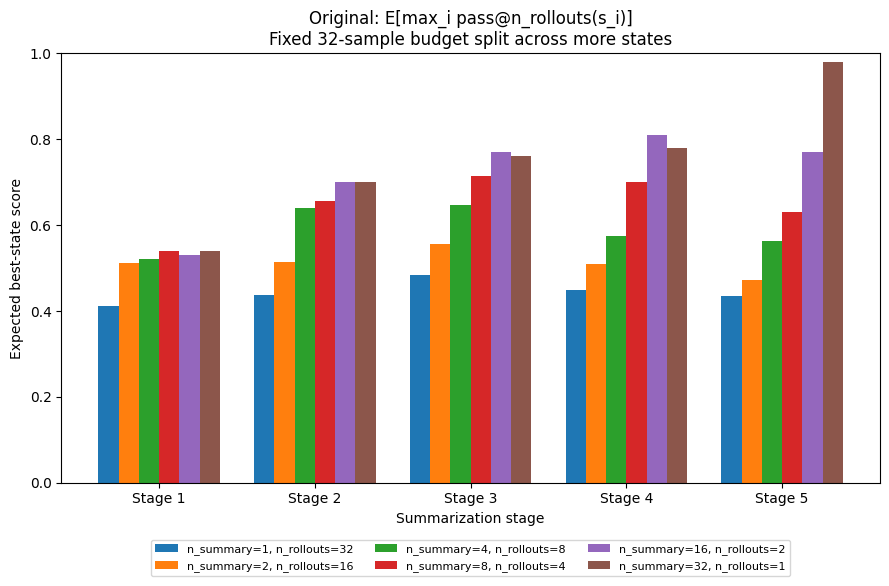

In [6]:
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
x = np.arange(len(stages))
n_splits = len(splits)
width = 0.13
offsets = np.linspace(-(n_splits-1)/2, (n_splits-1)/2, n_splits) * width

fig, ax = plt.subplots(figsize=(9, 6))
for (n_summary, n_rollouts), color, offset in zip(splits, colors, offsets):
    sub = results[(results['n_summary']==n_summary) & (results['n_rollouts']==n_rollouts)]
    vals = [sub[sub['stage']==s]['best_state_passK'].values[0] for s in stages]
    ax.bar(x + offset, vals, width=width, color=color, label=f'n_summary={n_summary}, n_rollouts={n_rollouts}')
ax.set_xticks(x)
ax.set_xticklabels([f'Stage {s}' for s in stages])
ax.set_xlabel('Summarization stage')
ax.set_ylabel('Expected best-state score')
ax.set_ylim(0, 1.0)
ax.set_title('Original: E[max_i pass@n_rollouts(s_i)]\nFixed 32-sample budget split across more states')
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()


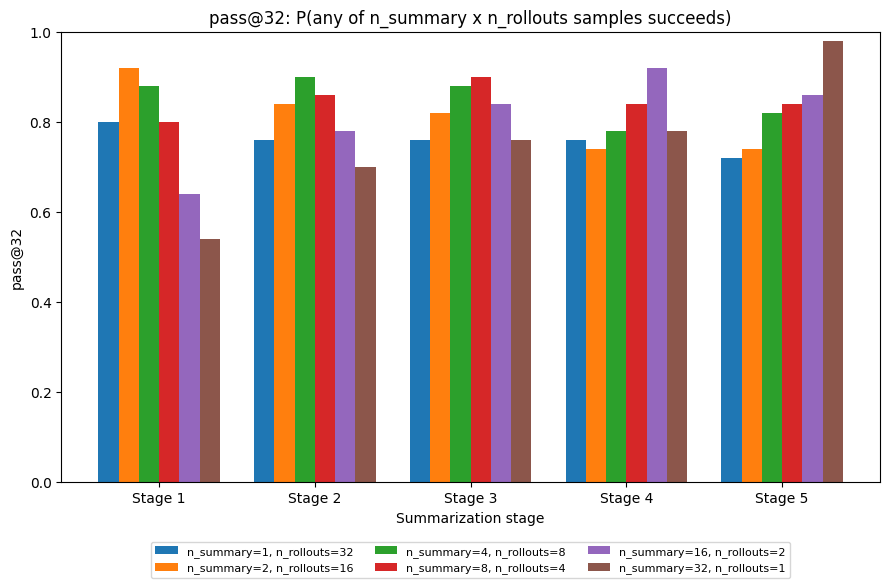

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
for (n_summary, n_rollouts), color, offset in zip(splits, colors, offsets):
    sub = results[(results['n_summary']==n_summary) & (results['n_rollouts']==n_rollouts)]
    vals = [sub[sub['stage']==s]['direct_pass32'].values[0] for s in stages]
    ax.bar(x + offset, vals, width=width, color=color, label=f'n_summary={n_summary}, n_rollouts={n_rollouts}')
ax.set_xticks(x)
ax.set_xticklabels([f'Stage {s}' for s in stages])
ax.set_xlabel('Summarization stage')
ax.set_ylabel('pass@32')
ax.set_ylim(0, 1.0)
ax.set_title('pass@32: P(any of n_summary x n_rollouts samples succeeds)')
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()


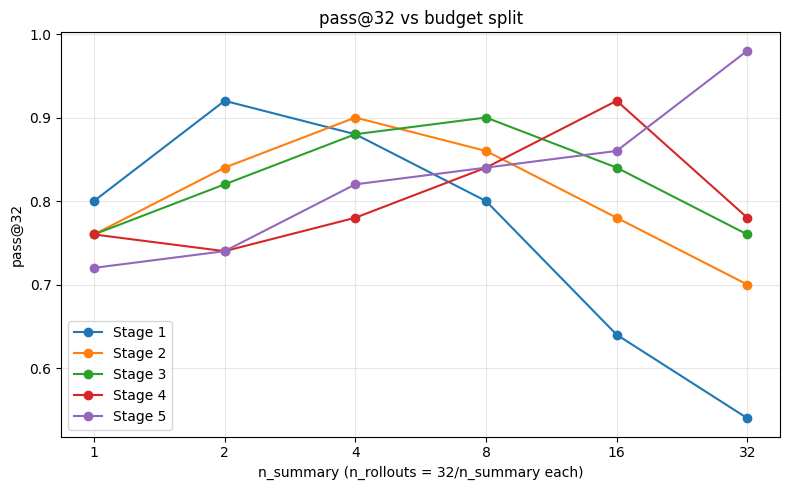

In [8]:
# Line plot: direct pass@32 vs n_summary per stage
fig, ax = plt.subplots(figsize=(8, 5))

for stage, color in zip(stages, ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']):
    sub = results[results['stage']==stage].sort_values('n_summary')
    ax.plot(sub['n_summary'], sub['direct_pass32'], marker='o', label=f'Stage {stage}', color=color)

ax.set_xlabel('n_summary (n_rollouts = 32/n_summary each)')
ax.set_ylabel('pass@32')
ax.set_title('pass@32 vs budget split')
ax.set_xscale('log', base=2)
ax.set_xticks([1,2,4,8,16,32])
ax.set_xticklabels(['1','2','4','8','16','32'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# Summary table
pivot = results.pivot_table(index=['n_summary','n_rollouts'], columns='stage', values='direct_pass32')
pivot.columns = [f'Stage {s}' for s in pivot.columns]
pivot.index = [f'n_summary={n}, n_rollouts={k}' for n,k in pivot.index]
print('Direct pass@32 by budget split and stage:')
print(pivot.round(3).to_string())


Direct pass@32 by budget split and stage:
                            Stage 1  Stage 2  Stage 3  Stage 4  Stage 5
n_summary=1, n_rollouts=32     0.80     0.76     0.76     0.76     0.72
n_summary=2, n_rollouts=16     0.92     0.84     0.82     0.74     0.74
n_summary=4, n_rollouts=8      0.88     0.90     0.88     0.78     0.82
n_summary=8, n_rollouts=4      0.80     0.86     0.90     0.84     0.84
n_summary=16, n_rollouts=2     0.64     0.78     0.84     0.92     0.86
n_summary=32, n_rollouts=1     0.54     0.70     0.76     0.78     0.98
